# Session 3: Introduction to Image Processing Techniques and Image Restoration

We will cover the following topics in this tutorial:
- Image visualization and histogram visualization
- Histogram matching and equalization
- Denoising
- Spatial filtering

**Learning objectives** — by the end of this notebook you should be able to:
- Compute and interpret an image histogram and its cumulative distribution function (CDF)
- Implement histogram equalization and histogram matching from scratch
- Add and characterize common noise models (Gaussian, salt-and-pepper)
- Denoise images with linear (Gaussian) and non-linear (median) spatial filters, and explain when each is appropriate

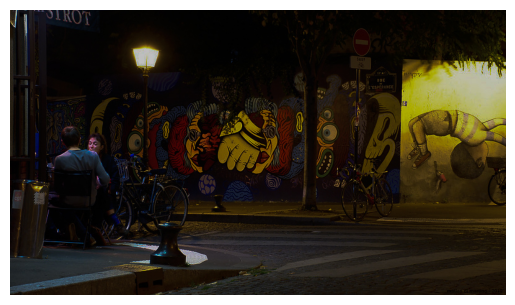

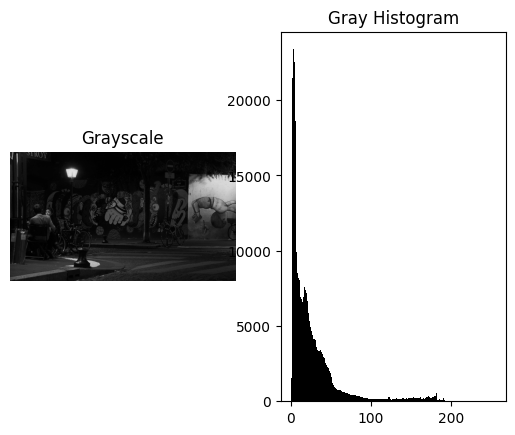

In [3]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

np.random.seed(0)

# Read the test image
image = cv2.imread("data/test1.jpg")

# Convert the image from BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Visualize the image
plt.imshow(image)
plt.axis("off")
plt.show()


# Ex 1 (a): Plot the image histogram
# define a function: plot_image_histogram(image)
# which will be used in the next exercises
# TODO: your code here


def plot_image_histogram(img):
    # Grayscale + Histogram
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    plt.subplot(121), plt.imshow(g, cmap='gray'), plt.axis("off"), plt.title("Grayscale")
    plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")
    plt.show()

plot_image_histogram(image)




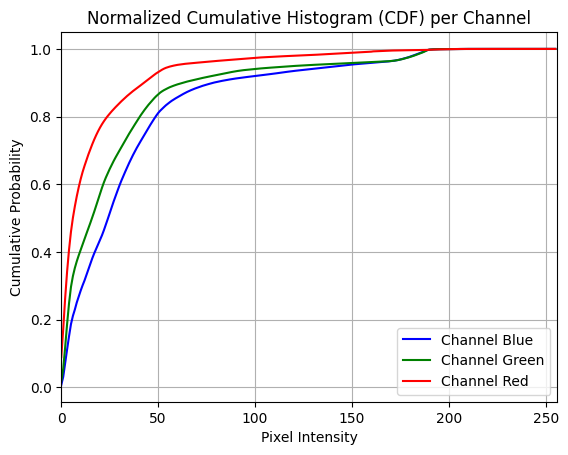

In [13]:
# Ex 1 (b): Plot the image normalized cumulative histogram
# define a function: plot_image_cdf(image)
# which will be used in the next exercises
# TODO: your code here


def plot_image_cdf(image):
    plt.figure()
    
    # Grayscale image
    if len(image.shape) == 2:
        hist, _ = np.histogram(image.flatten(), 256, [0, 256])
        cdf = hist.cumsum()
        plt.plot(cdf / cdf.max(), color='black', label='Gray')
    # Color image (assumes RGB or BGR)
    else:
        colors = ('b', 'g', 'r')  # adjust order if RGB: ('r', 'g', 'b')
        labels = ('Blue', 'Green', 'Red')
        for i, (col, label) in enumerate(zip(colors, labels)):
            hist, _ = np.histogram(image[:, :, i].flatten(), 256, [0, 256])
            cdf = hist.cumsum()
            plt.plot(cdf / cdf.max(), color=col, label=f'Channel {label}')
            
    plt.title('Normalized Cumulative Histogram (CDF) per Channel')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Cumulative Probability')
    plt.xlim([0, 256])
    plt.legend()
    plt.grid(True)
    plt.show()
plot_image_cdf(image)


## Let's fix the image dynamic range by performing histogram equalization

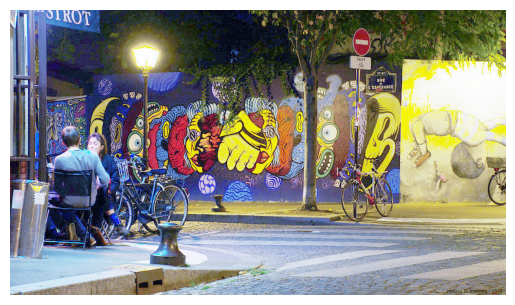

In [20]:
import numpy as np
import cv2

#cv2.equalizeHist(image)

# Ex 2: Implement image equalization (only using numpy)
# define a method called histogram_equalization(image)
# TODO: your code here


# Apply histogram equalization to the image
#equalized_image = histogram_equalization(image)

# Visualize the equalized image
#plt.imshow(equalized_image)
#plt.axis("off")
#plt.show()
#plot_image_histogram(equalized_image)

def histogram_equalization(image):
    def _equalize_channel(channel):
        hist, _ = np.histogram(channel.flatten(), 256, [0, 256])
        cdf = hist.cumsum()
        
        # Mask zeros to ignore empty bins
        cdf_masked = np.ma.masked_equal(cdf, 0)
        
        # Equalization formula: (CDF - CDF_min) / (N - CDF_min) * 255
        cdf_masked = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
        
        # Fill masked zeros and convert to uint8 LUT
        lut = np.ma.filled(cdf_masked, 0).astype('uint8')
        
        # Map original pixel values
        return lut[channel]
    if image.ndim == 2:
        return _equalize_channel(image)
    else:
        # Equalize each channel independently
        equalized = np.zeros_like(image)
        for c in range(image.shape[2]):
            equalized[:, :, c] = _equalize_channel(image[:, :, c])
        return equalized
# Apply histogram equalization to the image
equalized_image = histogram_equalization(image)
# Visualize the equalized image
plt.imshow(equalized_image, cmap='gray' if equalized_image.ndim == 2 else None)
plt.axis("off")
plt.show()

Note: `histogram_equalization` above equalizes a single, joint RGB histogram (all channels pooled together), which is simple but can shift hues — equalizing each channel independently, or only the luminance channel (e.g., V in HSV / Y in YCrCb), preserves hue better at the cost of a less aggressive contrast boost.

### Let's compare the cumulative distribution of these two images

**Ex 3:** Explain why the equalized image's CDF looks the way it does, compared to the original.

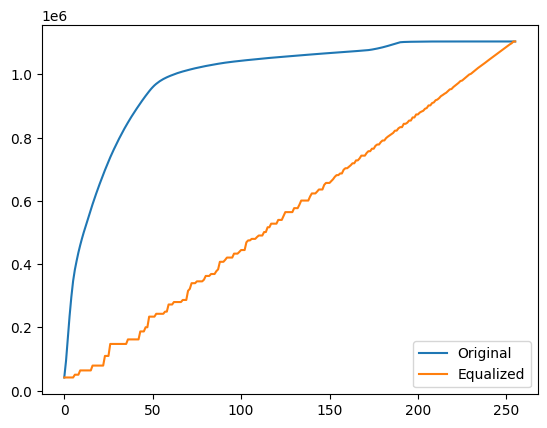

In [21]:
plt.plot(np.cumsum(np.histogram(image.ravel(), bins=256, range=[0, 256])[0]))
plt.plot(np.cumsum(np.histogram(equalized_image.ravel(), bins=256, range=[0, 256])[0]))
plt.legend(["Original", "Equalized"])

The original image have more dark pixels than the equalized. 

## Histogram matching

We will match the histogram of one image into another. 

((-0.5, 599.5, 399.5, -0.5), Text(0.5, 1.0, 'img2: Coffee'))

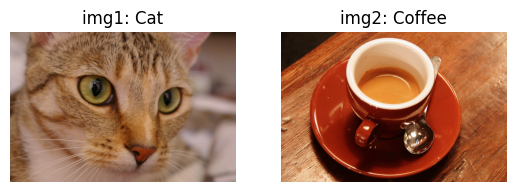

In [22]:
# We will get two test images from skimage library
from skimage import data

img1 = getattr(data, "cat")()
img2 = getattr(data, "coffee")()
plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.axis("off"), plt.title("img1: Cat")
plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.axis("off"), plt.title("img2: Coffee")

In [23]:
import numpy as np


# Ex 4: Implement histogram matching (only using numpy)
# define a method called histogram_matching(image, target_image)
# TODO: your code here

def histogram_matching(image, target_image):
    def _match_channel(src_chan, tgt_chan):
        # 1. Compute source & target histograms and normalized CDFs
        src_hist, _ = np.histogram(src_chan.flatten(), 256, [0, 256])
        tgt_hist, _ = np.histogram(tgt_chan.flatten(), 256, [0, 256])
        
        src_cdf = src_hist.cumsum() / src_hist.sum()
        tgt_cdf = tgt_hist.cumsum() / tgt_hist.sum()
        
        # 2. Build lookup table using linear interpolation (matching CDFs)
        lut = np.interp(src_cdf, tgt_cdf, np.arange(256)).astype('uint8')
        
        # 3. Map original pixels to target distribution
        return lut[src_chan]
    if image.ndim == 2:
        return _match_channel(image, target_image)
    else:
        matched = np.zeros_like(image)
        for c in range(image.shape[2]):
            matched[:, :, c] = _match_channel(image[:, :, c], target_image[:, :, c])
        return matched


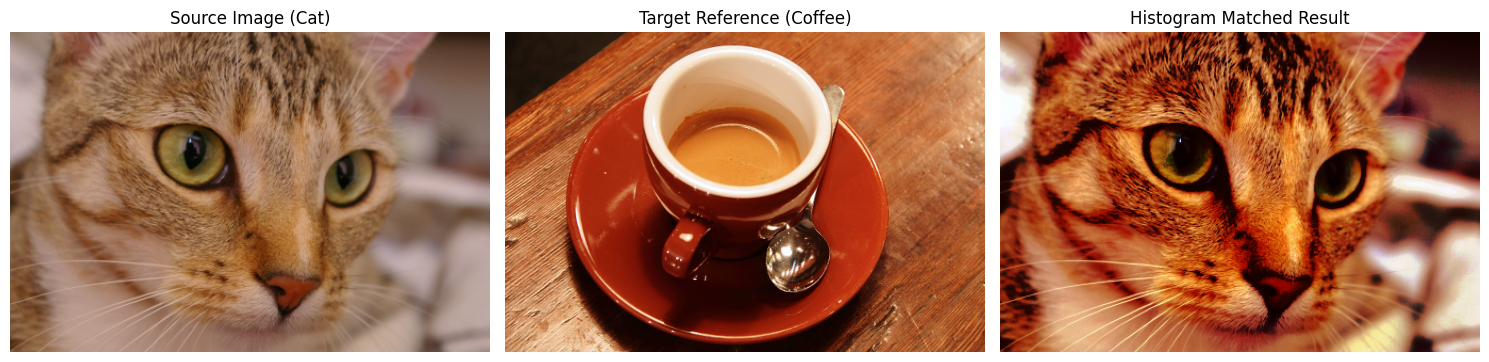

In [26]:
img1_matched = histogram_matching(img1, img2)
# Visualize Source, Reference Target, and Matched Output
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img1)
axes[0].set_title("Source Image (Cat)")
axes[0].axis("off")
axes[1].imshow(img2)
axes[1].set_title("Target Reference (Coffee)")
axes[1].axis("off")
axes[2].imshow(img1_matched)
axes[2].set_title("Histogram Matched Result")
axes[2].axis("off")
plt.tight_layout()
plt.show()

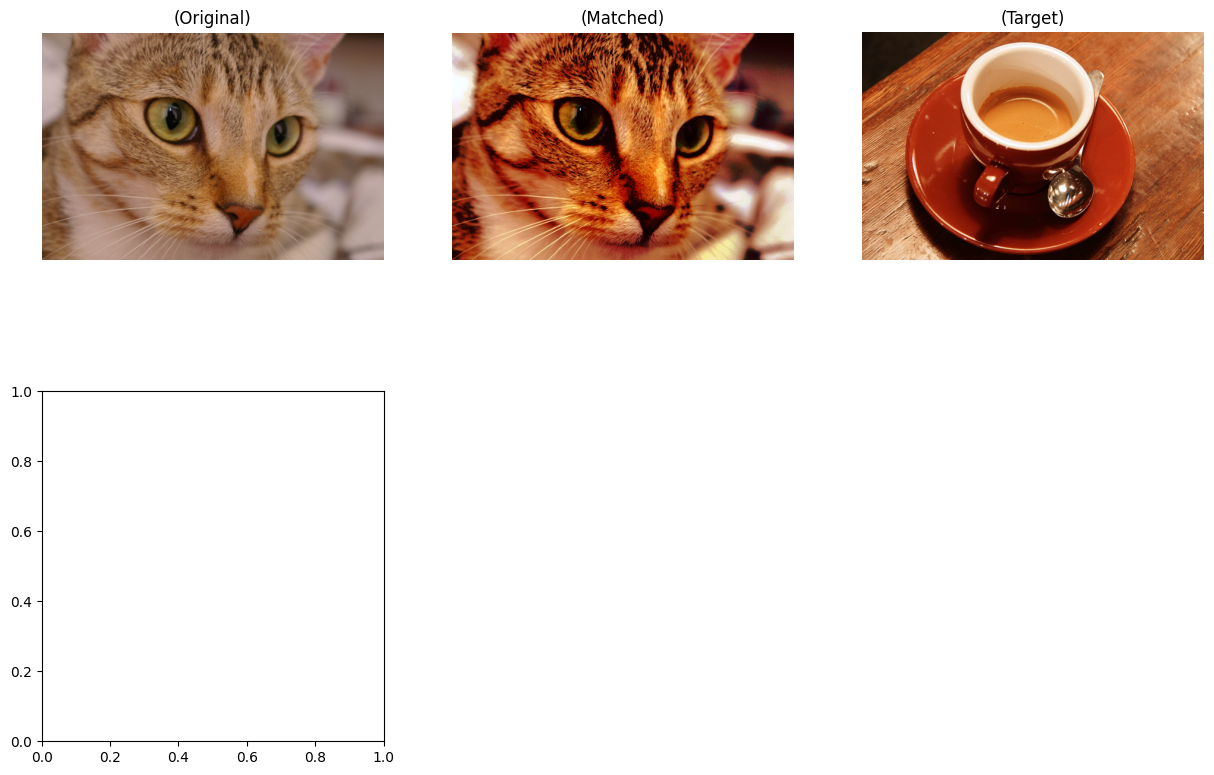

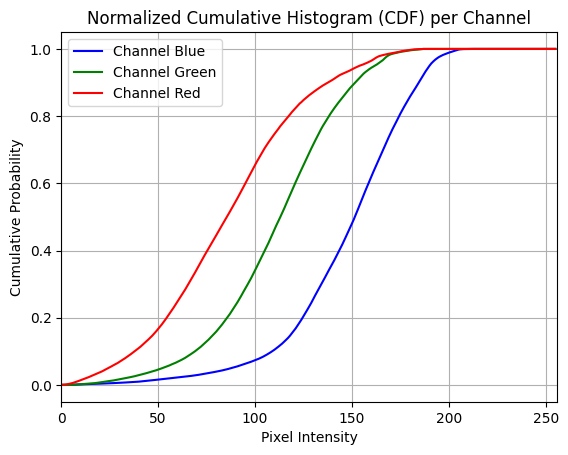

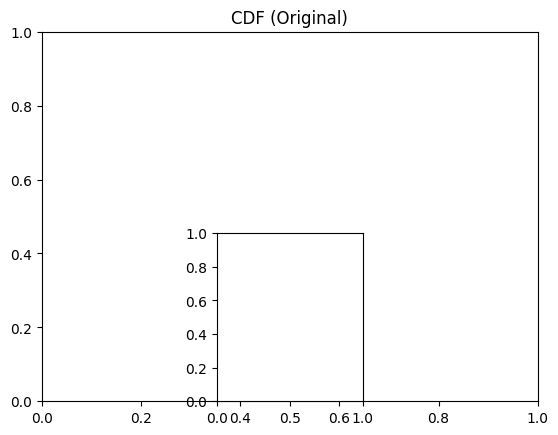

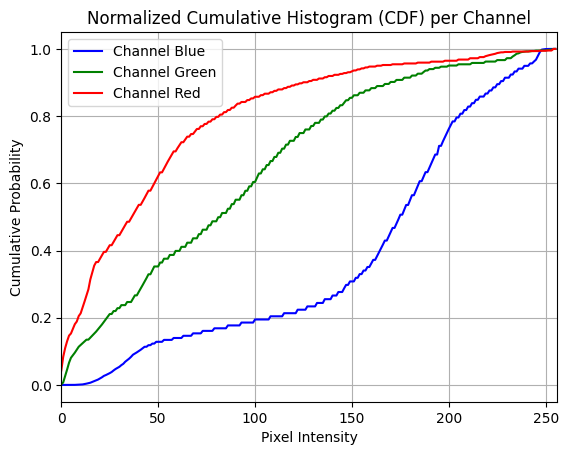

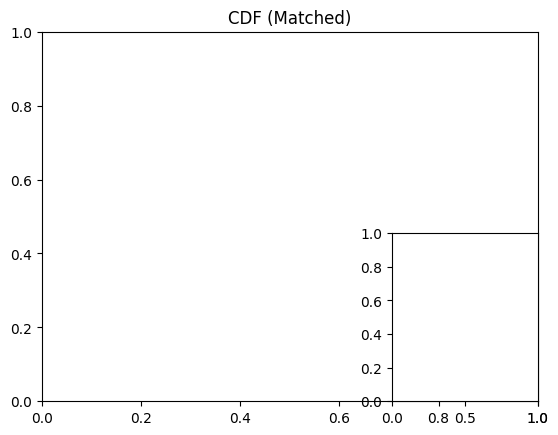

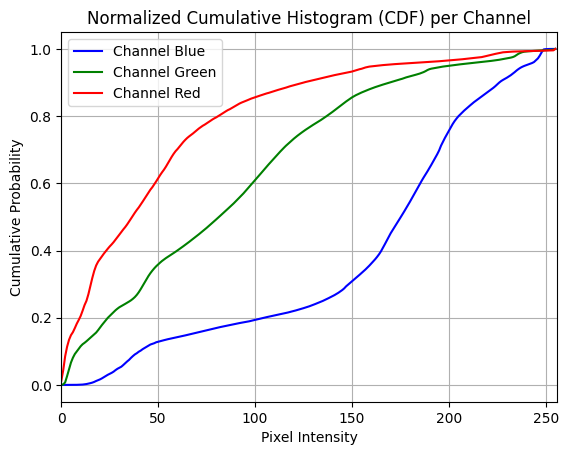

(<Axes: >, None, Text(0.5, 1.0, 'CDF (Target)'))

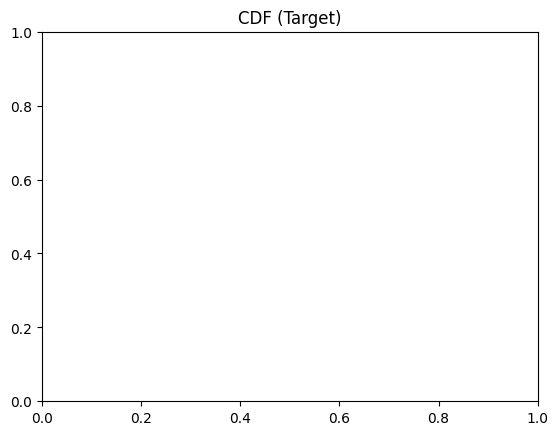

In [27]:
# Let's visualize the results with the method you defined above
img1_matched = histogram_matching(img1, img2)
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1), plt.imshow(img1), plt.axis("off"), plt.title("(Original)")
plt.subplot(2, 3, 2), plt.imshow(img1_matched), plt.axis("off"), plt.title("(Matched)")
plt.subplot(2, 3, 3), plt.imshow(img2), plt.axis("off"), plt.title("(Target)")
plt.subplot(2, 3, 4), plot_image_cdf(img1), plt.title("CDF (Original)"),
plt.subplot(2, 3, 5), plot_image_cdf(img1_matched), plt.title("CDF (Matched)")
plt.subplot(2, 3, 6), plot_image_cdf(img2), plt.title("CDF (Target)")

## Introduction to spatial filtering and image denoising

### Adding noise to clean images

(<matplotlib.image.AxesImage at 0x1af7ecf6660>,
 (-0.5, 450.5, 299.5, -0.5),
 Text(0.5, 1.0, 'Original Image'))

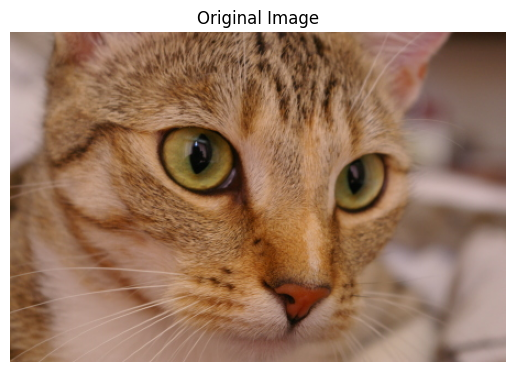

In [40]:
from skimage import data

# Let's use a test image from skimage library
img = getattr(data, "cat")()
plt.imshow(img), plt.axis("off"), plt.title("Original Image")

In [ ]:
# Ex 5 (a): Using only numpy, create a function
# capable of adding Gaussian noise to an image
# define a method called
# add_gaussian_noise(image, mean, std) -> image
# TODO: your code here

def add_gaussian_noise(image, mean, std):
    # 1. Generate normal distribution noise matching image shape
    noise = np.random.normal(mean, std, image.shape)
    
    # 2. Add noise and clip values to valid [0, 255] range
    noisy_image = np.clip(image.astype(np.float64) + noise, 0, 255)
    
    # 3. Return as original uint8 type
    return noisy_image.astype(np.uint8)
blured_image = add_gaussian_noise(img,5,50)
plt.imshow(blured_image), plt.axis("off"), plt.title("Original Image")

In [ ]:


# Ex 5 (b): Using only numpy, create a function
# capable of adding Salt and Pepper noise to an image
# define a method called add_salt_and_pepper_noise(image, amount)
# amount is the percentage of individual channel values to corrupt (we sample flat indices
# into the raveled RGB array, so a given pixel may have only one or two of its channels
# flipped to salt/pepper, not necessarily all three)
# add_salt_and_pepper_noise(image, amount) -> image
# TODO: your code here

In [ ]:
# Let's visualize the results for gaussian noise of different standard deviations.
plt.figure(figsize=(20, 15))
sigma = np.arange(0, 100, 30)
n = len(sigma)
for i, s in enumerate(sigma):
    plt.subplot(1, n, i + 1), plt.imshow(add_gaussian_noise(img, 0, s)), plt.axis("off"), plt.title(
        f"Gaussian Noise (sigma={s})"
    )

In [ ]:
# Let's visualize the results for salt and pepper noise of different amounts.
plt.figure(figsize=(20, 15))
amounts = np.arange(0, 100, 30)
n = len(amounts)
for i, a in enumerate(amounts):
    plt.subplot(1, n, i + 1), plt.imshow(add_salt_and_pepper_noise(img, a)), plt.axis("off"), plt.title(
        f"Salt and Pepper (amount={a})"
    )

### Image denoising

In [ ]:
# Ex 6: Remove noise by using a Gaussian filter
# implement a method called
# remove_noise(image, sigma) -> image
# you can use opencv (tip: cv2.GaussianBlur)
# Bonus, you can try to implement this from scratch (using numpy)
# TODO: your code here

In [ ]:
from skimage import data

clean_img = getattr(data, "cat")()
noisy_img = add_gaussian_noise(clean_img, 0, 30)
sigma = 10
denoised_img = remove_noise(noisy_img, sigma)

plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1), plt.imshow(clean_img), plt.axis("off"), plt.title("Original")
plt.subplot(1, 3, 2), plt.imshow(noisy_img), plt.axis("off"), plt.title("Noisy")
plt.subplot(1, 3, 3), plt.imshow(denoised_img), plt.axis("off"), plt.title("Denoised")

Plot the MSE for a given level of noise (fixed noise sigma) for different kernel widths. 

In [ ]:
clean_img = getattr(data, "cat")()  # get a clean image
noisy_img = add_gaussian_noise(clean_img, 0, 30)  # compute a noisy image for a fixed sigma

sigmas = np.arange(0.5, 30, 1)  # sigmas to test for denoising (start > 0 so the filter does something)


# Ex 7: Check the denoising MSE for different kernel sigmas
# TODO: your code here

plt.plot(sigmas, mse_values), plt.xlabel("Sigma"), plt.ylabel("MSE"), plt.title("MSE vs Sigma")

## Denoising salt-and-pepper noise

Gaussian filtering assumes noise that varies smoothly (like Gaussian noise) — averaging neighboring pixels cancels it out. Salt-and-pepper noise is different: a small fraction of pixels are replaced by extreme outliers (0 or 255), and a linear average gets dragged toward those outliers. A **median filter**, which replaces each pixel with the median of its neighborhood, is much more robust to this kind of noise because the median discards outliers instead of averaging them in.

**Ex 8:** Denoise the salt-and-pepper image below with (a) the Gaussian filter from Ex 6 and (b) a median filter (`cv2.medianBlur` or `scipy.ndimage.median_filter`). Compare the results visually and with MSE, and explain why the median filter wins.

In [ ]:
clean_img = getattr(data, "cat")()
sp_img = add_salt_and_pepper_noise(clean_img, 10)


# TODO: your code here

plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1), plt.imshow(clean_img), plt.axis("off"), plt.title("Original")
plt.subplot(1, 4, 2), plt.imshow(sp_img), plt.axis("off"), plt.title("Salt & pepper")
plt.subplot(1, 4, 3), plt.imshow(gaussian_denoised), plt.axis("off"), plt.title(f"Gaussian (MSE={mse_gaussian:.1f})")
plt.subplot(1, 4, 4), plt.imshow(median_denoised), plt.axis("off"), plt.title(f"Median (MSE={mse_median:.1f})")
plt.show()

print(f"MSE Gaussian filter: {mse_gaussian:.2f}")
print(f"MSE Median filter:   {mse_median:.2f}")
assert mse_median < mse_gaussian, "Median filter should beat Gaussian on salt-and-pepper noise"